Cell 1: Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Cell 2: Load Dataset

In [4]:
df = pd.read_csv(r"C:\Users\lekhy\Downloads\Lab 23 Wholesale customers data.csv")

Cell 3: Display Data

In [7]:
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


Cell 4: Shape

In [9]:
df.shape

(440, 8)

Cell 5: Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


Cell 6: Describe

In [11]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


Cell 7: Missing Values

In [12]:
df.isnull().sum()

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Cell 8: Duplicate Values

In [13]:
df.duplicated().sum()

np.int64(0)

Cell 9: Remove Duplicates

In [14]:
df = df.drop_duplicates()

Cell 10: Histogram

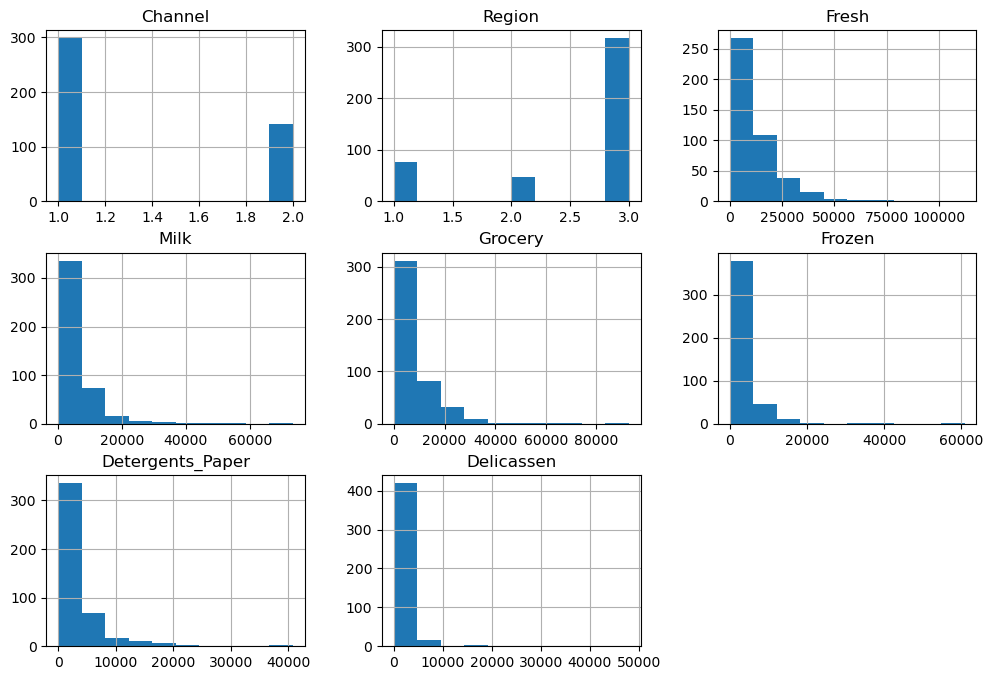

In [15]:
df.hist(figsize=(12,8))
plt.show()

Cell 11: Bar Plot

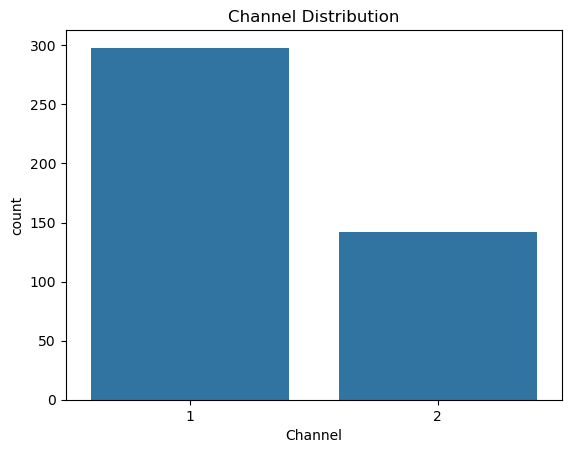

In [16]:
sns.countplot(x='Channel', data=df)
plt.title("Channel Distribution")
plt.show()

Cell 12: Heatmap

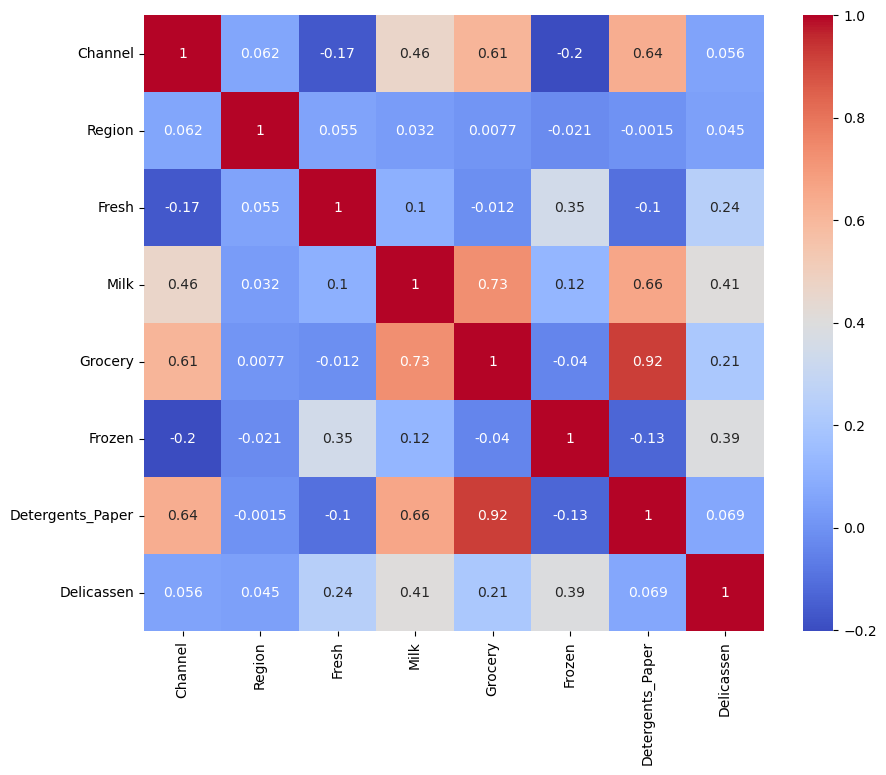

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Cell 13: Define X and y

In [18]:
X = df.drop("Channel", axis=1)
y = df["Channel"]

Cell 14: Train Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Cell 15: StandardScaler

In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Cell 16: Logistic Regression

In [21]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

acc1 = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", acc1)

print(classification_report(y_test, y_pred_lr))

print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.9204545454545454
              precision    recall  f1-score   support

           1       0.95      0.94      0.95        65
           2       0.83      0.87      0.85        23

    accuracy                           0.92        88
   macro avg       0.89      0.90      0.90        88
weighted avg       0.92      0.92      0.92        88

[[61  4]
 [ 3 20]]


Cell 17: KNN

In [22]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

acc2 = accuracy_score(y_test, y_pred_knn)

print("Accuracy:", acc2)

print(classification_report(y_test, y_pred_knn))

print(confusion_matrix(y_test, y_pred_knn))

Accuracy: 0.8863636363636364
              precision    recall  f1-score   support

           1       0.97      0.88      0.92        65
           2       0.72      0.91      0.81        23

    accuracy                           0.89        88
   macro avg       0.85      0.89      0.86        88
weighted avg       0.90      0.89      0.89        88

[[57  8]
 [ 2 21]]


Cell 18: Decision Tree

In [23]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

acc3 = accuracy_score(y_test, y_pred_dt)

print("Accuracy:", acc3)

print(classification_report(y_test, y_pred_dt))

print(confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.8409090909090909
              precision    recall  f1-score   support

           1       0.92      0.86      0.89        65
           2       0.67      0.78      0.72        23

    accuracy                           0.84        88
   macro avg       0.79      0.82      0.80        88
weighted avg       0.85      0.84      0.84        88

[[56  9]
 [ 5 18]]


Cell 19: Random Forest

In [24]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

acc4 = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", acc4)

print(classification_report(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.8977272727272727
              precision    recall  f1-score   support

           1       0.97      0.89      0.93        65
           2       0.75      0.91      0.82        23

    accuracy                           0.90        88
   macro avg       0.86      0.90      0.88        88
weighted avg       0.91      0.90      0.90        88

[[58  7]
 [ 2 21]]


Cell 20: Support Vector Machine (SVC)

In [25]:
svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

acc5 = accuracy_score(y_test, y_pred_svm)

print("Accuracy:", acc5)

print(classification_report(y_test, y_pred_svm))

print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.8977272727272727
              precision    recall  f1-score   support

           1       0.97      0.89      0.93        65
           2       0.75      0.91      0.82        23

    accuracy                           0.90        88
   macro avg       0.86      0.90      0.88        88
weighted avg       0.91      0.90      0.90        88

[[58  7]
 [ 2 21]]


Cell 21: Compare All Models

In [26]:
result = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        acc1,
        acc2,
        acc3,
        acc4,
        acc5
    ]
})

print(result)

                 Model  Accuracy
0  Logistic Regression  0.920455
1                  KNN  0.886364
2        Decision Tree  0.840909
3        Random Forest  0.897727
4                  SVM  0.897727


Cell 22: Best Model

In [27]:
best_model = result.loc[result["Accuracy"].idxmax()]

print("Best Model")

print(best_model)

Best Model
Model       Logistic Regression
Accuracy               0.920455
Name: 0, dtype: object
